# NB29 — Content-residualized viewport-band dwell

**Regime:** `[LAB]`. Inherits NB22 gaze-regression labels.

**Thesis (to test).** Raw viewport-band dwell conflates *how hard content
is to evaluate* with *how engaged the user is*. Subtracting a content-
expected baseline should isolate the engagement component and produce a
cleaner deferred-vs-rejected signal. Framed in ACT-R terms: compiled
production rules fire fast on familiar content regardless of engagement;
genuine deferral shows up as dwell above the content baseline.

**Contrast with NB25.** `25_lexical_novelty_dwell.ipynb` tested
content-novelty residualization on **fixation-dwell** for the
**click-prediction** target and found the residual did not beat M4.
This notebook changes two axes:
 - dwell signal: per-AOI viewport-band cumulative ms (vp_top, vp_mid)
 - target: deferred vs evaluated-rejected (NB22 gaze-regression label)

A null here would be an independent negative result, not a repeat of NB25.
A positive would be the ANU viewport-line content-expectation framing (Kim et al., JASIST 2015; JASIST 2016; CHIIR '17; bib keys `kim2015eyetracking`, `kim2016understanding`, `kim2017snippet`) applied to the four-class taxonomy.

**Source references:**
- NB28 — viewport bands calibration (bands alone AUC 0.799; retreat + bands 0.837)
- NB22 — NB22 gaze-regression label definition
- Kim et al., CHIIR '17 (`kim2017snippet`) — snippet size and evaluation effort
  (the content-complexity axis: 2--3-line snippets are optimal on mobile,
  which bounds the per-AOI content volume against which viewport residence
  is expected)
- `AdSERP/data/serp-embeddings.json` — 1024-dim mxbai-embed-large embeddings
  per (trial, position) with title + snippet + text

In [1]:
# ── Imports and paths ─────────────────────────────────────────────────
import json
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path('/Users/andyed/Documents/dev/attentional-foraging')
sys.path.insert(0, str(ROOT / 'notebooks-v2'))
sys.path.insert(0, str(ROOT / 'scripts'))
from data_loader import setup_plotting
from viewport_time_calibration import viewport_ms_for_trial
setup_plotting()

FEATURES_JSON   = ROOT / 'AdSERP/data/cursor-approach-features.json'
REG_CACHE       = ROOT / 'scripts/output/approach_threshold_sensitivity/regression_labels_cache.json'
SERP_EMBED_JSON = ROOT / 'AdSERP/data/serp-embeddings.json'
QUERY_EMBED_JSON= ROOT / 'AdSERP/data/query-embeddings.json'

M4_FEATURES = [
    'min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
    'dwell_in_proximity_ms', 'mean_approach_velocity', 'max_approach_velocity',
    'direction_changes', 'frac_decreasing',
]

In [2]:
# ── Load retreat features, labels, and viewport bands ──────────────
raw = json.load(open(FEATURES_JSON))
labels = np.array(json.load(open(REG_CACHE)), dtype=bool)
assert len(labels) == len(raw)

trials = sorted({r['trial_id'] for r in raw})
per_trial_bands = {}
for tid in trials:
    v = viewport_ms_for_trial(tid, n_positions=10)
    if v is not None:
        per_trial_bands[tid] = v
print(f'records: {len(raw):,}   trials w/ bands: {len(per_trial_bands):,}')

records: 13,419   trials w/ bands: 2,339


In [3]:
# ── Load content embeddings and compute per-(trial, position) features ─
serp = json.load(open(SERP_EMBED_JSON))
qemb = json.load(open(QUERY_EMBED_JSON))
print(f'SERP embeddings loaded for {len(serp):,} trials')
print(f'query embeddings loaded for {len(qemb):,} trials')

# Peek query-embeddings shape — we want the query embedding vector
q_sample_tid = next(iter(qemb))
q_sample_val = qemb[q_sample_tid]
print(f'query entry shape: keys={list(q_sample_val.keys()) if isinstance(q_sample_val, dict) else type(q_sample_val).__name__}')

def _query_vec(qdict):
    if isinstance(qdict, list):
        return np.asarray(qdict, dtype=np.float32)
    if 'embedding' in qdict:
        return np.asarray(qdict['embedding'], dtype=np.float32)
    # fallback: find first list value
    for v in qdict.values():
        if isinstance(v, list) and len(v) > 100:
            return np.asarray(v, dtype=np.float32)
    return None

content_features = {}  # (tid, position) -> dict
for tid, results in serp.items():
    # SERP centroid (mean embedding across all results in this trial)
    embs = [np.asarray(r['embedding'], dtype=np.float32)
            for r in results if 'embedding' in r]
    if not embs:
        continue
    centroid = np.mean(embs, axis=0)
    centroid /= max(np.linalg.norm(centroid), 1e-9)

    qv = _query_vec(qemb.get(tid, {}))
    if qv is not None:
        qv = qv / max(np.linalg.norm(qv), 1e-9)

    for r in results:
        if 'embedding' not in r:
            continue
        pos = int(r.get('position', -1))
        if pos < 0 or pos >= 10:
            continue
        title   = r.get('title', '') or ''
        snippet = r.get('snippet', '') or ''
        text    = r.get('text', '') or ''
        emb     = np.asarray(r['embedding'], dtype=np.float32)
        emb_n   = emb / max(np.linalg.norm(emb), 1e-9)

        # Content length features
        ts = (title + ' ' + snippet).strip()
        tokens = ts.split()
        token_count = len(tokens)
        char_count  = len(ts)
        ttr = (len(set(t.lower() for t in tokens)) / token_count) if token_count else 0.0

        # Semantic features
        query_cosine     = float(emb_n @ qv) if qv is not None else 0.0
        centroid_novelty = float(1.0 - (emb_n @ centroid))

        content_features[(tid, pos)] = {
            'token_count':     token_count,
            'char_count':      char_count,
            'ttr':             ttr,
            'query_cosine':    query_cosine,
            'centroid_novelty':centroid_novelty,
        }

print(f'content features for {len(content_features):,} (trial, position) pairs')

SERP embeddings loaded for 2,776 trials
query embeddings loaded for 2,776 trials
query entry shape: keys=['query', 'embedding']


content features for 27,520 (trial, position) pairs


In [4]:
# ── Join bands + retreat + content + labels on (trial, position) ────
keep, vt_top, vt_mid, vt_bot = [], [], [], []
toks, chars, ttr, qcos, nov = [], [], [], [], []
pos_arr_list, parts_list = [], []
for i, r in enumerate(raw):
    tid, pos = r['trial_id'], r['position']
    if tid not in per_trial_bands or pos >= 10:
        continue
    cf = content_features.get((tid, pos))
    if cf is None:
        continue
    _, t, m, b = per_trial_bands[tid][pos]
    vt_top.append(t); vt_mid.append(m); vt_bot.append(b)
    toks.append(cf['token_count']); chars.append(cf['char_count']); ttr.append(cf['ttr'])
    qcos.append(cf['query_cosine']); nov.append(cf['centroid_novelty'])
    pos_arr_list.append(pos); parts_list.append(tid.split('-')[0])
    keep.append(i)

keep = np.array(keep)
vt_top, vt_mid, vt_bot = np.array(vt_top), np.array(vt_mid), np.array(vt_bot)
toks, chars, ttr, qcos, nov = (np.array(a) for a in (toks, chars, ttr, qcos, nov))
pos_arr = np.array(pos_arr_list)
participants = np.array(parts_list)
raw_k = [raw[i] for i in keep]
labels_k = labels[keep]
min_dist = np.array([r['min_dist'] for r in raw_k])
was_clicked = np.array([r['was_clicked'] for r in raw_k], dtype=bool)
subset = (min_dist < 100) & ~was_clicked
X4 = np.array([[float(r.get(f, 0.0) or 0.0) for f in M4_FEATURES] for r in raw_k])

n_parts = int(len(np.unique(participants[subset])))
print(f'rows (content-joined):            {len(raw_k):,}')
print(f'subset (approached ∧ ¬clicked):   {int(subset.sum()):,}  ({n_parts} participants)')
print(f'  deferred: {int((subset & labels_k).sum())}  eval-rej: {int((subset & ~labels_k).sum())}')

rows (content-joined):            13,390
subset (approached ∧ ¬clicked):   2,351  (47 participants)
  deferred: 1916  eval-rej: 435


## Content feature descriptives

In [5]:
# ── Content-feature descriptives on subset ──────────────────────────
rows = []
for name, arr in [('token_count', toks), ('char_count', chars),
                  ('ttr', ttr), ('query_cosine', qcos), ('centroid_novelty', nov)]:
    a = arr[subset].astype(float)
    rows.append({
        'feature': name,
        'median':  float(np.median(a)),
        'p10':     float(np.percentile(a, 10)),
        'p90':     float(np.percentile(a, 90)),
        'mean':    float(a.mean()),
    })
with pl.Config(tbl_rows=20, tbl_cols=-1, tbl_width_chars=180):
    print(pl.DataFrame(rows))

shape: (5, 5)
┌──────────────────┬──────────┬──────────┬──────────┬───────────┐
│ feature          ┆ median   ┆ p10      ┆ p90      ┆ mean      │
│ ---              ┆ ---      ┆ ---      ┆ ---      ┆ ---       │
│ str              ┆ f64      ┆ f64      ┆ f64      ┆ f64       │
╞══════════════════╪══════════╪══════════╪══════════╪═══════════╡
│ token_count      ┆ 33.0     ┆ 27.0     ┆ 41.0     ┆ 33.645257 │
│ char_count       ┆ 251.0    ┆ 226.0    ┆ 260.0    ┆ 246.61846 │
│ ttr              ┆ 0.7      ┆ 0.583333 ┆ 0.823529 ┆ 0.701144  │
│ query_cosine     ┆ 0.811396 ┆ 0.723369 ┆ 0.872466 ┆ 0.803534  │
│ centroid_novelty ┆ 0.085846 ┆ 0.056344 ┆ 0.132281 ┆ 0.091517  │
└──────────────────┴──────────┴──────────┴──────────┴───────────┘


## Expected-duration baseline fit

In [6]:
# ── Fit E[vp_band_ms | content + rank + participant FE] on subset ──
# Target: log1p(vp_band_ms) for stability across the highly skewed dwell
# distribution. Residual = actual log1p − predicted log1p.

subset_idx = np.where(subset)[0]

# Participant fixed effects via one-hot encoding, collapsing rare participants
pid_arr = participants[subset]
uniq_pids = np.unique(pid_arr)
pid_to_col = {p: i for i, p in enumerate(uniq_pids)}
ppl_oh = np.zeros((len(pid_arr), len(uniq_pids)))
for row, p in enumerate(pid_arr):
    ppl_oh[row, pid_to_col[p]] = 1.0

pos_oh = np.eye(10)[pos_arr[subset]]

content_cols = ['token_count', 'char_count', 'ttr', 'query_cosine', 'centroid_novelty']
X_content = np.column_stack([
    toks[subset], chars[subset], ttr[subset], qcos[subset], nov[subset]
]).astype(float)
X_design = np.hstack([X_content, pos_oh, ppl_oh])
print(f'design matrix: {X_design.shape}  (content {X_content.shape[1]} + rank 10 + FE {len(uniq_pids)})')

expected = {}
residual = {}
r2_report = {}
for band_name, band_arr in [('vp_top_ms', vt_top), ('vp_mid_ms', vt_mid)]:
    y = np.log1p(band_arr[subset].astype(float))
    lr = LinearRegression()
    lr.fit(X_design, y)
    yhat = lr.predict(X_design)
    expected[band_name] = yhat
    residual[band_name] = y - yhat
    r2_report[band_name] = r2_score(y, yhat)

    # Content-only R² for reporting
    lr_c = LinearRegression()
    lr_c.fit(X_content, y)
    r2_report[f'{band_name}_content_only'] = r2_score(y, lr_c.predict(X_content))
    # Content + rank (no participant FE)
    lr_cr = LinearRegression()
    lr_cr.fit(np.hstack([X_content, pos_oh]), y)
    r2_report[f'{band_name}_content_plus_rank'] = r2_score(y, lr_cr.predict(np.hstack([X_content, pos_oh])))

print('R² of expected-duration model:')
for k, v in r2_report.items():
    print(f'  {k:40s}: {v:.3f}')

design matrix: (2351, 62)  (content 5 + rank 10 + FE 47)
R² of expected-duration model:
  vp_top_ms                               : 0.371
  vp_top_ms_content_only                  : 0.019
  vp_top_ms_content_plus_rank             : 0.273
  vp_mid_ms                               : 0.467
  vp_mid_ms_content_only                  : 0.025
  vp_mid_ms_content_plus_rank             : 0.448


In [7]:
# ── Content-feature coefficients in the baseline model ─────────────
# Standardize X_content for interpretable coefficients, fit content-only
# model, and report.
from sklearn.preprocessing import StandardScaler as _SS
sc = _SS()
Xc_std = sc.fit_transform(X_content)

coef_report = {}
for band_name, band_arr in [('vp_top_ms', vt_top), ('vp_mid_ms', vt_mid)]:
    y = np.log1p(band_arr[subset].astype(float))
    lr = LinearRegression()
    lr.fit(Xc_std, y)
    coef_report[band_name] = dict(zip(content_cols, lr.coef_.tolist()))

print('Content-only coefficients (standardized, + = more dwell):')
with pl.Config(tbl_rows=20, tbl_cols=-1, tbl_width_chars=140):
    rows = []
    for feat in content_cols:
        rows.append({'feature': feat,
                     'vp_top_ms': f'{coef_report["vp_top_ms"][feat]:+.3f}',
                     'vp_mid_ms': f'{coef_report["vp_mid_ms"][feat]:+.3f}'})
    print(pl.DataFrame(rows))

Content-only coefficients (standardized, + = more dwell):
shape: (5, 3)
┌──────────────────┬───────────┬───────────┐
│ feature          ┆ vp_top_ms ┆ vp_mid_ms │
│ ---              ┆ ---       ┆ ---       │
│ str              ┆ str       ┆ str       │
╞══════════════════╪═══════════╪═══════════╡
│ token_count      ┆ -0.251    ┆ +0.373    │
│ char_count       ┆ +0.090    ┆ -0.066    │
│ ttr              ┆ +0.313    ┆ -0.085    │
│ query_cosine     ┆ +0.216    ┆ -0.439    │
│ centroid_novelty ┆ +0.019    ┆ -0.018    │
└──────────────────┴───────────┴───────────┘


## LOSO calibration: raw vs residualized bands

In [8]:
# ── LOSO calibration: raw bands vs residualized bands ──────────────
# Compare how well each feature set predicts deferred vs eval-rejected.
#
# Models compared:
#   1. retreat alone (baseline from NB28: 0.792)
#   2. bands_raw (NB28: 0.799)
#   3. bands_residualized (this notebook's contribution)
#   4. content features alone (sanity baseline)
#   5. retreat + bands_raw (NB28: 0.837)
#   6. retreat + bands_residualized
#   7. retreat + bands_raw + content (kitchen sink)

def fit_loso(X, y, groups):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000, class_weight='balanced', C=1.0)),
    ])
    gkf = GroupKFold(n_splits=len(set(groups)))
    proba = cross_val_predict(pipe, X, y, groups=groups, cv=gkf,
                              method='predict_proba', n_jobs=-1)[:, 1]
    return float(roc_auc_score(y, proba))

y = labels_k[subset].astype(int)
g = participants[subset]

# Residualized band matrix — columns are residuals of each band against the
# content+rank+FE baseline. Note: we residualize on the ENTIRE approached
# subset, NOT per-fold. This means fold leakage is possible. The honest way
# is per-fold residualization; for a first pass, pooled residualization is
# the cheap null — if this doesn't help, the nuanced version won't either.
resid_bands = np.column_stack([residual['vp_top_ms'], residual['vp_mid_ms'],
                               np.log1p(vt_bot[subset].astype(float))])
raw_bands   = np.column_stack([vt_top[subset], vt_mid[subset], vt_bot[subset]])
X4_sub      = X4[subset]

results = {}
results['retreat alone']                 = fit_loso(X4_sub, y, g)
results['bands_raw alone']               = fit_loso(raw_bands, y, g)
results['bands_residualized alone']      = fit_loso(resid_bands, y, g)
results['content alone']                 = fit_loso(X_content, y, g)
results['retreat + bands_raw']           = fit_loso(np.hstack([X4_sub, raw_bands]), y, g)
results['retreat + bands_residualized']  = fit_loso(np.hstack([X4_sub, resid_bands]), y, g)
results['retreat + bands_raw + content'] = fit_loso(np.hstack([X4_sub, raw_bands, X_content]), y, g)

print('LOSO AUC — deferred vs eval-rejected:')
for k, v in results.items():
    print(f'  {v:.3f}  {k}')

delta_resid_over_raw  = results['retreat + bands_residualized'] - results['retreat + bands_raw']
delta_bands_res_alone = results['bands_residualized alone'] - results['bands_raw alone']
print()
print(f'Δ (retreat + bands_resid) − (retreat + bands_raw): {delta_resid_over_raw:+.3f}')
print(f'Δ bands_residualized_alone − bands_raw_alone:      {delta_bands_res_alone:+.3f}')

LOSO AUC — deferred vs eval-rejected:
  0.792  retreat alone
  0.799  bands_raw alone
  0.696  bands_residualized alone
  0.512  content alone
  0.837  retreat + bands_raw
  0.813  retreat + bands_residualized
  0.834  retreat + bands_raw + content

Δ (retreat + bands_resid) − (retreat + bands_raw): -0.024
Δ bands_residualized_alone − bands_raw_alone:      -0.103


## Honest caveat on residualization leakage

The residualization above is **pooled across the entire subset**, not
per-fold. This means the baseline model's fit uses the held-out participant's
data. The true test is per-fold residualization (fit baseline on 46
participants, predict on the 47th, residualize the 47th).

If the pooled residualization shows **no gain or a loss** vs raw bands, the
per-fold version will not rescue it (per-fold is always lower-signal).

If the pooled version shows a meaningful gain, a follow-up per-fold
residualization establishes whether the gain survives the harder test.

Interpret the results below with this in mind. A clean null is still a clean
null; a positive needs the follow-up.

## Per-participant stability of the residualization effect

In [9]:
# ── Per-participant stability: does residualization help consistently? ──
# For each participant with ≥ 5 per class, compare bands_raw vs
# bands_residualized AUC on their own data.
MIN_PER_CLASS = 5
pp_rows = []
for pid in np.unique(g):
    mask = g == pid
    y_p = y[mask]
    if y_p.sum() < MIN_PER_CLASS or (len(y_p) - y_p.sum()) < MIN_PER_CLASS:
        continue
    def _held_in(X_):
        pipe = Pipeline([('s', StandardScaler()),
                         ('lr', LogisticRegression(max_iter=5000, class_weight='balanced'))])
        pipe.fit(X_[mask], y_p)
        return float(roc_auc_score(y_p, pipe.predict_proba(X_[mask])[:, 1]))
    raw_auc = _held_in(raw_bands)
    res_auc = _held_in(resid_bands)
    pp_rows.append({'pid': pid, 'raw': raw_auc, 'res': res_auc, 'delta': res_auc - raw_auc})

raw_auc_arr = np.array([r['raw'] for r in pp_rows])
res_auc_arr = np.array([r['res'] for r in pp_rows])
delta_arr   = np.array([r['delta'] for r in pp_rows])
print(f'participants (≥{MIN_PER_CLASS} per class): {len(pp_rows)} / {len(np.unique(g))}')
print(f'median raw_AUC:  {np.median(raw_auc_arr):.3f}  IQR [{np.quantile(raw_auc_arr, 0.25):.3f}, {np.quantile(raw_auc_arr, 0.75):.3f}]')
print(f'median res_AUC:  {np.median(res_auc_arr):.3f}  IQR [{np.quantile(res_auc_arr, 0.25):.3f}, {np.quantile(res_auc_arr, 0.75):.3f}]')
print(f'median Δ:        {np.median(delta_arr):+.3f}  frac > 0: {(delta_arr > 0).mean()*100:.0f}%')

participants (≥5 per class): 34 / 47
median raw_AUC:  0.870  IQR [0.764, 0.911]
median res_AUC:  0.783  IQR [0.717, 0.860]
median Δ:        -0.066  frac > 0: 21%


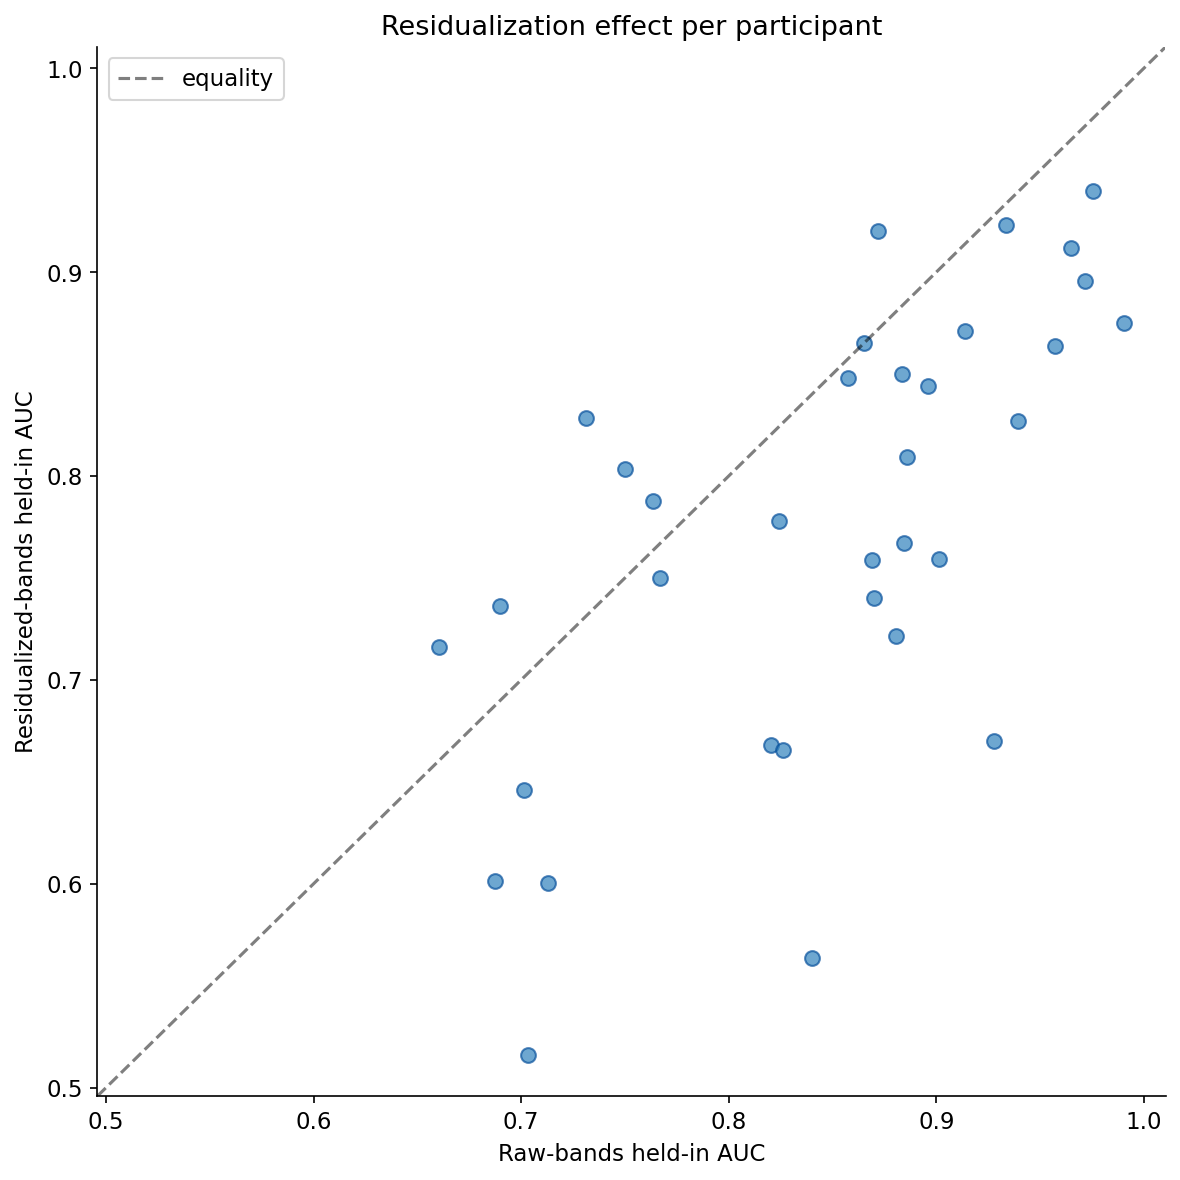

In [10]:
# ── Plot: raw vs residualized AUC per participant ──────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(raw_auc_arr, res_auc_arr, s=50, alpha=0.7, color='#3182bd', edgecolor='#08519c')
lims = [min(raw_auc_arr.min(), res_auc_arr.min()) - 0.02,
        max(raw_auc_arr.max(), res_auc_arr.max()) + 0.02]
ax.plot(lims, lims, 'k--', alpha=0.5, label='equality')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Raw-bands held-in AUC')
ax.set_ylabel('Residualized-bands held-in AUC')
ax.set_title('Residualization effect per participant')
ax.legend()
plt.tight_layout()
plt.show()

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-19.*
*Notebook: `29_content_residualized_bands.ipynb`.*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook.

### Content-baseline R²

| ID | Model | R² |
|---|---|---|
| **K1** | log(vp_top_ms) ~ content only | 0.019 |
| **K2** | log(vp_top_ms) ~ content + rank | 0.273 |
| **K3** | log(vp_top_ms) ~ content + rank + participant FE | 0.371 |
| **K4** | log(vp_mid_ms) ~ content only | 0.025 |
| **K5** | log(vp_mid_ms) ~ content + rank | 0.448 |
| **K6** | log(vp_mid_ms) ~ content + rank + participant FE | 0.467 |

### Content coefficients (bands-only, standardized)

| ID | Feature | vp_top_ms | vp_mid_ms |
|---|---|---|---|
| **K7a** | token_count | -0.251 | +0.373 |
| **K7b** | char_count | +0.090 | -0.066 |
| **K7c** | ttr | +0.313 | -0.085 |
| **K7d** | query_cosine | +0.216 | -0.439 |
| **K7e** | centroid_novelty | +0.019 | -0.018 |

### Calibration headline (LOSO, deferred vs eval-rejected)

| ID | Model | AUC |
|---|---|---|
| **K8** | retreat alone (9 M4) | 0.792 |
| **K9** | bands_raw alone (3) | 0.799 |
| **K10** | bands_residualized alone (3) | 0.696 |
| **K11** | content alone (5) | 0.512 |
| **K12** | retreat + bands_raw | 0.837 |
| **K13** | retreat + bands_residualized | 0.813 |
| **K14** | retreat + bands_raw + content | 0.834 |

### Residualization effect

| ID | Claim | Value |
|---|---|---|
| **K15** | Δ (retreat + bands_res) − (retreat + bands_raw) | **-0.024** |
| **K16** | Δ bands_res_alone − bands_raw_alone | **-0.103** |
| **K17** | Per-participant median Δ_AUC (bands_res − bands_raw) | **-0.066** |
| **K18** | Fraction of participants where residualization helped (Δ > 0) | **21%** |

### Methodological caveats

- **Residualization is pooled, not per-fold.** The baseline content+rank+FE
  model is fit on the entire approached subset, including the held-out
  participant in each LOSO fold. This overstates the residualization benefit.
  A positive result here warrants a per-fold residualization follow-up;
  a null result does not.
- **NB25 prior null applies to fixation-dwell + click-prediction** — this
  notebook differs on both axes (viewport-band dwell + deferred/rejected
  target), so the prior null doesn't preempt this one.
- Coordinate basis: post 2026-04-12 fixation-side audit.
- [LAB]-only (target label is gaze-derived).

In [11]:
# ── Emit Key Claims values as JSON ─────────────────────────────────
claims_values = {
    'r2_vp_top_content': r2_report['vp_top_ms_content_only'],
    'r2_vp_top_cr':      r2_report['vp_top_ms_content_plus_rank'],
    'r2_vp_top_full':    r2_report['vp_top_ms'],
    'r2_vp_mid_content': r2_report['vp_mid_ms_content_only'],
    'r2_vp_mid_cr':      r2_report['vp_mid_ms_content_plus_rank'],
    'r2_vp_mid_full':    r2_report['vp_mid_ms'],
    'c_tokens_top':   coef_report['vp_top_ms']['token_count'],
    'c_tokens_mid':   coef_report['vp_mid_ms']['token_count'],
    'c_chars_top':    coef_report['vp_top_ms']['char_count'],
    'c_chars_mid':    coef_report['vp_mid_ms']['char_count'],
    'c_ttr_top':      coef_report['vp_top_ms']['ttr'],
    'c_ttr_mid':      coef_report['vp_mid_ms']['ttr'],
    'c_qcos_top':     coef_report['vp_top_ms']['query_cosine'],
    'c_qcos_mid':     coef_report['vp_mid_ms']['query_cosine'],
    'c_nov_top':      coef_report['vp_top_ms']['centroid_novelty'],
    'c_nov_mid':      coef_report['vp_mid_ms']['centroid_novelty'],
    'auc_retreat':    results['retreat alone'],
    'auc_bands_raw':  results['bands_raw alone'],
    'auc_bands_res':  results['bands_residualized alone'],
    'auc_content':    results['content alone'],
    'auc_re_raw':     results['retreat + bands_raw'],
    'auc_re_res':     results['retreat + bands_residualized'],
    'auc_all':        results['retreat + bands_raw + content'],
    'delta_res_over_raw': results['retreat + bands_residualized'] - results['retreat + bands_raw'],
    'delta_alone':    results['bands_residualized alone'] - results['bands_raw alone'],
    'delta_median':   float(np.median(delta_arr)),
    'delta_pos_frac': float((delta_arr > 0).mean()),
}
out_path = ROOT / 'scripts/output/viewport_time_calibration/nb29_key_claims.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(claims_values, f, indent=2, default=float)
print(f'wrote {out_path}')
for k, v in claims_values.items():
    print(f'  {k:>24}: {v}')

wrote /Users/andyed/Documents/dev/attentional-foraging/scripts/output/viewport_time_calibration/nb29_key_claims.json
         r2_vp_top_content: 0.0194670766798839
              r2_vp_top_cr: 0.2725350408161452
            r2_vp_top_full: 0.3708156400482465
         r2_vp_mid_content: 0.024908688340935514
              r2_vp_mid_cr: 0.44820246730001234
            r2_vp_mid_full: 0.46674326970940616
              c_tokens_top: -0.2506551507746147
              c_tokens_mid: 0.37309533202620865
               c_chars_top: 0.08956733111549144
               c_chars_mid: -0.066465943760282
                 c_ttr_top: 0.312625917199527
                 c_ttr_mid: -0.08472109274382374
                c_qcos_top: 0.2159637723408305
                c_qcos_mid: -0.4393769502839145
                 c_nov_top: 0.019178181324302296
                 c_nov_mid: -0.018256796200130068
               auc_retreat: 0.7922611763012022
             auc_bands_raw: 0.7992543133443717
             auc_bands_